In [1]:
import os
import torch
import argparse

import shared.utils as su
from tasks.eval_chiral_retrieval import load_data
from utils.chiral_retrieval_metrics import (
    compute_metrics,
    print_metrics_as_latex_row,
)
import pandas as pd
import numpy as np
import json


def load_data_video_cls(
    data_root='/scratch/shared/beegfs/piyush/datasets/MMEB-V2',
    cfg_path='/users/piyush/projects/VLM2Vec/experiments/public/eval/video_cls.yaml'
):
    # Load meta config
    meta_config = su.io.load_yml(cfg_path)

    # Generate dataframe of video paths
    df_video = []
    for ds_key in su.log.tqdm_iterator(meta_config, desc='Gathering video paths'):
        file_name = meta_config[ds_key]['json_name']
        data_file = f'{data_root}/video-tasks/data/{file_name}'
        assert os.path.exists(data_file)
        data = su.io.load_jsonl(data_file)

        ds_name = os.path.basename(meta_config[ds_key]['frame_root'])
        for d in data:
            video_id = d['video_id']
            video_dir = f"{data_root}/video-tasks/frames/{ds_name}/{video_id}"
            assert os.path.isdir(video_dir)
            df_video.append(
                dict(ds_key=ds_key, ds_name=ds_name, video_id=video_id, video_dir=video_dir)
            )
    df_video = pd.DataFrame(df_video)
    assert len(df_video.video_id.unique()) == len(df_video)
    return df_video


def load_data_video_ret(
    data_root = '/scratch/shared/beegfs/piyush/datasets/MMEB-V2',
    cfg_path = '/users/piyush/projects/VLM2Vec/experiments/public/eval/video_ret.yaml',
    video_root = "/scratch/shared/beegfs/piyush/datasets/MMEB-V2/video-tasks/frames/data/ziyan/video_retrieval"
):
    # Load meta config
    meta_config = su.io.load_yml(cfg_path)

    # Load video root
    # This defines the huggingface repo and subset for each dataset
    # (repo, subset, split)
    json_paths = {
        "MSR-VTT": ("VLM2Vec/MSR-VTT", "test_1k", "test"),
        "MSVD": ("VLM2Vec/MSVD", None, "test"),
        "DiDeMo": ("VLM2Vec/DiDeMo", None, "test"),
        # "YouCook2": ("VLM2Vec/YouCook2", None, "val"), # HF version compatibility issue
        "YouCook2": ("lmms-lab/YouCook2", None, "val"),
        "VATEX": ("VLM2Vec/VATEX", None, "test"),
    }

    video_id_extractor = {
        "MSR-VTT": lambda x: x['video_id'],
        "MSVD": lambda x: x['video_id'],
        "DiDeMo": lambda x: x['video'].split('/')[-1].split('.')[0],
        "YouCook2": lambda x: x['id'],
        "VATEX": lambda x: x['videoID'],
    }


    df_video = {'video_id': [], 'video_dir': []}
    from datasets import load_dataset
    for ds_key in su.log.tqdm_iterator(meta_config, desc='Processing datasets'):
        print(ds_key)
        repo, subset, split = json_paths[ds_key]
        df = pd.DataFrame(load_dataset(repo, subset)[split])
        video_dir = f"{video_root}/{ds_key}/frames"
        video_ids = os.listdir(video_dir)
        assert len(video_ids) == len(df)
        # print(df.iloc[0])
        
        df['video_id'] = df.apply(lambda x: video_id_extractor[ds_key](x), axis=1)
        df['video_dir'] = df['video_id'].apply(lambda x: f"{video_root}/{ds_key}/frames/{x}")
        df_video['video_id'].extend(df['video_id'].tolist())
        df_video['video_dir'].extend(df['video_dir'].tolist())
        print('-' * 100)
    df_video = pd.DataFrame(df_video)
    assert len(df_video.video_id.unique()) == len(df_video)
    return df_video

In [2]:
df_cls = load_data_video_cls()
df_cls['video_path'] = df_cls['video_dir'].apply(lambda x: x.replace('video-tasks/frames', 'video-tasks/videos') + '.mp4')
df_cls = df_cls[df_cls['video_path'].apply(os.path.exists)]

df_ret = load_data_video_ret()
df_ret['video_path'] = df_ret['video_dir'].apply(lambda x: x.replace('video-tasks/frames', 'video-tasks/videos') + '.mp4')
df_ret = df_ret[df_ret['video_path'].apply(os.path.exists)]

df_cls.shape, df_ret.shape

Gathering video paths:   0%|          | 0/5 [00:00<?, ?it/s]

Processing datasets:   0%|          | 0/5 [00:00<?, ?it/s]

MSR-VTT
----------------------------------------------------------------------------------------------------
MSVD
----------------------------------------------------------------------------------------------------
DiDeMo
----------------------------------------------------------------------------------------------------
YouCook2
----------------------------------------------------------------------------------------------------
VATEX
----------------------------------------------------------------------------------------------------


((4433, 5), (10331, 3))

### Load model

In [3]:
from models.modeling_encoders import EncoderForTarsier2

# model_path = "/work/piyush/pretrained_checkpoints/Tarsier2-7b-0115"
model_path = "/work/piyush/experiments/CaRe/Tarsier2-7b-0115/covr/chiral10k-covr10k/merged_checkpoint"
model = EncoderForTarsier2.from_pretrained(
    model_path, dtype=torch.bfloat16, device_map="auto", attn_implementation="flash_attention_2",
)
su.misc.num_params(model.model)

The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.
Unrecognized keys in `rope_scaling` for 'rope_type'='default': {'mrope_section'}


Loading EncoderForTarsier2 from /work/piyush/experiments/CaRe/Tarsier2-7b-0115/covr/chiral10k-covr10k/merged_checkpoint


The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.
The model weights are not tied. Please use the `tie_weights` method before using the `infer_auto_device` function.


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

::: Number of total parameters in Tarsier2ForConditionalGeneration: 8291.376M


In [4]:
# Load video embeddings
feat_dir = "/scratch/shared/beegfs/piyush/datasets/MMEB-V2/features"

video_embs_cls = torch.load(f"{feat_dir}/tarsier2-tara-cia10k-covr10k_video_embeddings_mmebv2_video_cls.pt")
video_embs_ret = torch.load(f"{feat_dir}/tarsier2-tara-cia10k-covr10k_video_embeddings_mmebv2_video_ret.pt")

len(video_embs_cls), len(video_embs_ret)

(4432, 10331)

In [5]:
# Only keep those rows with videos available
df_cls = df_cls[df_cls.video_id.apply(lambda x: x in video_embs_cls)]
df_ret = df_ret[df_ret.video_id.apply(lambda x: x in video_embs_ret)]

df_cls.shape, df_ret.shape

((4432, 5), (10331, 3))

### Retrieval with re-ranking

In [6]:
data_root = '/scratch/shared/beegfs/piyush/datasets/MMEB-V2'
meta_config = su.io.load_yml(
    '/users/piyush/projects/VLM2Vec/experiments/public/eval/video_ret.yaml'
)

# This defines the huggingface repo and subset for each dataset
# (repo, subset, split)
json_paths = {
    "MSR-VTT": ("VLM2Vec/MSR-VTT", "test_1k", "test"),
    "MSVD": ("VLM2Vec/MSVD", None, "test"),
    "DiDeMo": ("VLM2Vec/DiDeMo", None, "test"),
    "YouCook2": ("lmms-lab/YouCook2", None, "val"),
    "VATEX": ("VLM2Vec/VATEX", None, "test"),
}
video_id_extractor = {
    "MSR-VTT": lambda x: x['video_id'],
    "MSVD": lambda x: x['video_id'],
    "DiDeMo": lambda x: x['video'].split('/')[-1].split('.')[0],
    "YouCook2": lambda x: x["id"],
    "VATEX": lambda x: x['videoID'],
}
video_root = "/scratch/shared/beegfs/piyush/datasets/MMEB-V2/video-tasks/frames/data/ziyan/video_retrieval"
captions_extractor = {
    "MSR-VTT": lambda x: [x["caption"]],
    "MSVD": lambda x: x["caption"],
    "DiDeMo": lambda x: [x["caption"]],
    "YouCook2": lambda x: [x['sentence']],
    "VATEX": lambda x: x["enCap"],
}

In [15]:
meta_config

{'MSR-VTT': {'dataset_parser': 'msrvtt',
  'dataset_name': 'MSR-VTT',
  'video_root': 'video-tasks/videos/video_ret/MSR-VTT/',
  'frame_root': 'video-tasks/frames/video_ret/MSR-VTT/',
  'num_sample_per_subset': 'None',
  'max_frames_saved': 64,
  'num_frames': 8,
  'eval_type': 'global'},
 'MSVD': {'dataset_parser': 'msvd',
  'dataset_name': 'MSVD',
  'video_root': 'video-tasks/videos/video_ret/MSVD/',
  'frame_root': 'video-tasks/frames/video_ret/MSVD/',
  'num_sample_per_subset': 'None',
  'max_frames_saved': 64,
  'num_frames': 8,
  'eval_type': 'global'},
 'DiDeMo': {'dataset_parser': 'didemo',
  'dataset_name': 'DiDeMo',
  'video_root': 'video-tasks/videos/video_ret/DiDeMo/',
  'frame_root': 'video-tasks/frames/video_ret/DiDeMo/',
  'num_sample_per_subset': 'None',
  'max_frames_saved': 64,
  'num_frames': 8,
  'eval_type': 'global'},
 'YouCook2': {'dataset_parser': 'youcook2',
  'dataset_name': 'YouCook2',
  'video_root': 'video-tasks/videos/video_ret/YouCook2/',
  'frame_root': 

In [7]:
def gather_text_embeddings(encoder, texts, ds_name):
    ZT = {}
    for text in su.log.tqdm_iterator(texts, desc=f'Computing text embeddings for {ds_name}'):
        with torch.no_grad():
            zt = encoder.encode_text(text)
            zt = torch.nn.functional.normalize(zt, dim=-1).squeeze(0).cpu().float()
        ZT[text] = zt
    return ZT

In [8]:
from datasets import load_dataset


ret_accs = {}
text_embeds = {}
for ds_key in meta_config:
    su.log.print_update(f"Processing {ds_key}")
    d = meta_config[ds_key]

    repo, subset, split = json_paths[ds_key]
    df = pd.DataFrame(load_dataset(repo, subset)[split])
    
    video_dir = f"{video_root}/{ds_key}/frames"
    video_ids = os.listdir(video_dir)
    assert len(video_ids) == len(df)
    df['video_id'] = df.apply(lambda x: video_id_extractor[ds_key](x), axis=1)

    print(json.dumps(df.iloc[0].to_dict(), indent=2))

    all_texts = [
        captions_extractor[ds_key](df.iloc[i].to_dict()) for i in range(len(df))
    ]
    all_texts = np.unique(np.concatenate(all_texts))
    text_embeds[ds_key] = gather_text_embeddings(model, all_texts, ds_key)

    break


Processing MSR-VTT..............................................................  
{
  "video_id": "video7020",
  "video": "video7020.mp4",
  "caption": "a woman creating a fondant baby and flower",
  "source": "MSR-VTT",
  "category": 10,
  "url": "https://www.youtube.com/watch?v=4KRMJNBjrEs",
  "start time": 221.77,
  "end time": 233.08,
  "id": 7020
}


Computing text embeddings for MSR-VTT:   0%|          | 0/995 [00:00<?, ?it/s]

From v4.47 onwards, when a model cache is to be returned, `generate` will return a `Cache` instance instead by default (as opposed to the legacy tuple of tuples format). If you want to keep returning the legacy format, please set `return_legacy_cache=True`.


In [12]:
def compute_video_text_score(model, video_path, caption):
    import torch
    from models.tarsier2.dataset.utils import format_one_sample

    instruction = "Retrieval relevant text with user's query"
    prompt = (
        "Judge whether the Video meets the requirements based on the Query text "
        "and the Instruction provided. Note that the answer can only be 'yes' or 'no'.\n"
        f"Query: {caption}\n"
        f"Instruction: {instruction}"
    )

    sample = format_one_sample(media_file=video_path, prompt=prompt)
    sample = model.super_processor(sample)
    model_inputs = {
        k: v.to(model.model.device)
        for k, v in sample.items()
        if isinstance(v, torch.Tensor)
    }

    tokenizer = model.processor.tokenizer
    yes_token_id = tokenizer.encode("yes", add_special_tokens=False)[0]
    no_token_id = tokenizer.encode("no", add_special_tokens=False)[0]

    with torch.inference_mode():
        outputs = model.model.generate(
            **model_inputs,
            max_new_tokens=1,
            output_scores=True,
            return_dict_in_generate=True,
            pad_token_id=model.processor.tokenizer.eos_token_id
        )

    logits = outputs.scores[0][0]  # (vocab_size,)
    logit_yes = logits[yes_token_id].float()
    logit_no = logits[no_token_id].float()

    score = torch.sigmoid(logit_yes - logit_no).item()
    return score


compute_video_text_score(model, '../assets/demo.mp4', "Video of sample")

0.9996485710144043

In [13]:
zt = torch.stack([text_embeds[ds_key][t] for t in text_embeds[ds_key]])
zt = torch.nn.functional.normalize(zt, dim=-1)

zt.shape

torch.Size([995, 3584])

In [14]:
# Use standard retrieval to get top K candidates

correct = []
K = 20
for i in su.log.tqdm_iterator(range(len(df)), desc='Reranking'):
    row = df.iloc[i].to_dict()
    video_id = row['video_id']
    video_path = df_ret[df_ret.video_id == video_id].iloc[0].video_path

    zv = video_embs_ret[video_id]
    zv = torch.nn.functional.normalize(zv, dim=-1)
    
    # Retrieve topK texts
    sims = (zv @ zt.T)
    topk = torch.topk(sims, k=K)
    indices = topk.indices

    # Re-ranking step
    scores = []
    captions = []
    for j in indices:
        cap = all_texts[j]
        s = compute_video_text_score(model, video_path, cap)
        scores.append(s)
        captions.append(cap)

    # Get prediction & gt
    pr = indices[np.argsort(-np.array(scores))[0]].item()
    gt = np.where(all_texts == row['caption'])[0][0]

    correct.append(gt == pr)
correct = np.array(correct)

Reranking:   0%|          | 0/1000 [00:00<?, ?it/s]

KeyboardInterrupt: 

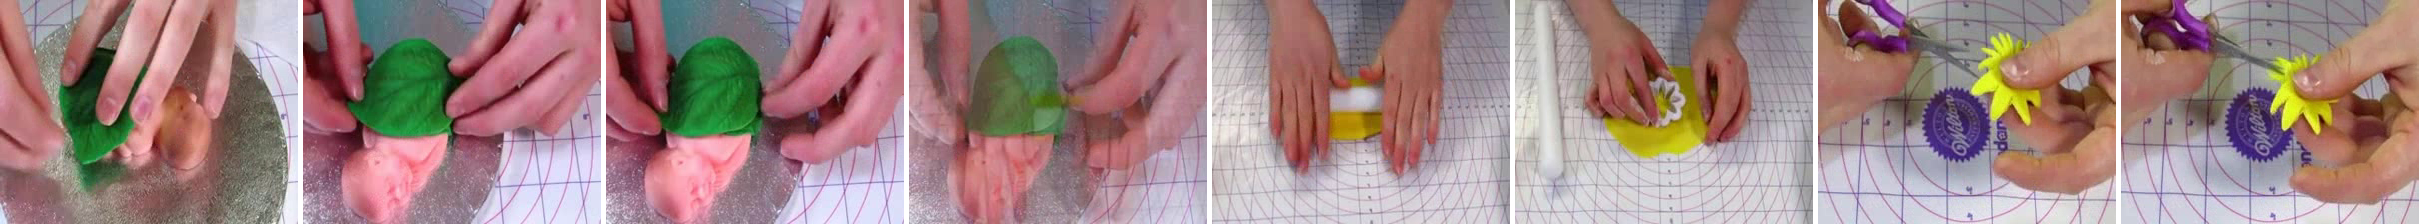

In [74]:
frames = su.video.load_frames_linspace(video_path, 8)
su.visualize.concat_images_with_border(frames)